In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import requests
import time

In [2]:
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

headers = {"User-Agent": "Mozilla/5.0"}
html = requests.get(url, headers=headers).text

sp500 = pd.read_html(html)[0]
tickers = sp500['Symbol'].tolist()

# Fix Yahoo format
tickers = [t.replace('.', '-') for t in tickers]

print("Total tickers:", len(tickers))
print(tickers[:10])

Total tickers: 503
['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A']


C:\Users\rafas\AppData\Local\Temp\ipykernel_13480\1215673065.py:6: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  sp500 = pd.read_html(html)[0]


In [3]:
batch_size = 50
all_data = []

for i in range(0, len(tickers), batch_size):
    batch = tickers[i:i+batch_size]
    print(f"Downloading batch {i//batch_size + 1}")
    
    data = yf.download(
        batch,
        start="2005-01-01",
        end="2024-03-31",
        interval='1mo',
        auto_adjust=True  # 🔥 KEY FIX
    )
    
    # Handle MultiIndex
    if isinstance(data.columns, pd.MultiIndex):
        if 'Close' in data.columns.levels[0]:
            data = data['Close']
        else:
            print("Close not found, skipping batch")
            continue
    else:
        # Single ticker case
        data = data[['Close']]
    
    # Drop empty tickers
    data = data.dropna(axis=1, how='all')
    
    all_data.append(data)
    
    time.sleep(1)

# Combine all batches
prices = pd.concat(all_data, axis=1)
prices = prices.loc[:, ~prices.columns.duplicated()]

print("Final number of tickers:", len(prices.columns))
prices.head()

[*********************100%***********************]  50 of 50 completed
[                       0%                       ]

[*********************100%***********************]  50 of 50 completed


[*********************100%***********************]  50 of 50 completed


[*********************100%***********************]  50 of 50 completed


[*********************100%***********************]  50 of 50 completed


...

[**********************92%*******************    ]  46 of 50 completed$SNDK: possibly delisted; no price data found  (1mo 2005-01-01 -> 2024-03-31) (Yahoo error = "Data doesn't exist for startDate = 1104555600, endDate = 1711857600")
[*********************100%***********************]  50 of 50 completed

1 Failed download:
['SNDK']: possibly delisted; no price data found  (1mo 2005-01-01 -> 2024-03-31) (Yahoo error = "Data doesn't exist for startDate = 1104555600, endDate = 1711857600")


[*********************100%***********************]  50 of 50 completed
[                       0%                       ]

[*********************100%***********************]  3 of 3 completed


Final number of tickers: 501


Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WST,WTW,WY,WYNN,XEL,XYL,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2005-01-01,13.185673,1.152078,NaN,NaN,13.184132,3.880722,18.055040,28.444420,22.065624,14.466598,...,10.764663,64.206871,11.184769,35.088360,8.300261,NaN,11.245901,67.769287,50.930000,NaN
2005-02-01,14.312804,1.344140,NaN,NaN,13.542979,4.382586,17.708500,30.868944,22.575932,14.406814,...,10.645700,65.651062,11.996743,38.304977,8.085793,NaN,11.860995,73.828598,49.869999,NaN
2005-03-01,13.239347,1.248558,NaN,NaN,13.728503,4.230442,16.738169,33.578411,22.255919,14.744701,...,9.900084,61.202370,12.356858,36.255112,7.839391,NaN,12.597747,66.875496,47.490002,NaN
2005-04-01,12.374619,1.080466,NaN,NaN,14.476479,4.225159,15.040094,29.735001,21.005789,10.791584,...,10.910804,55.857086,12.376705,28.334009,7.936961,NaN,11.418456,69.978119,47.759998,NaN
2005-05-01,14.318769,1.191329,NaN,NaN,14.287583,4.717513,16.135180,33.119999,22.834787,11.907337,...,11.586177,57.226387,11.572152,25.074587,8.514439,NaN,12.495691,65.818314,42.560001,NaN


In [4]:
momentum = prices.pct_change(12)
momentum = momentum.dropna(how='all')

momentum.head()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WST,WTW,WY,WYNN,XEL,XYL,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2006-01-01,0.533696,0.963848,NaN,NaN,-0.018928,0.479445,0.225019,0.396759,0.118972,0.321990,...,0.190121,-0.080645,0.150965,-0.014948,0.117789,NaN,0.076559,-0.125555,-0.115845,NaN
2006-02-01,0.500000,0.526750,NaN,NaN,-0.015680,0.363548,0.293753,0.248828,0.048855,0.336747,...,0.278095,-0.107863,0.050452,-0.071538,0.096625,NaN,-0.013492,-0.194645,-0.114899,NaN
2006-03-01,0.691442,0.505160,NaN,NaN,-0.066565,0.442058,0.260209,0.040847,0.071514,0.390084,...,0.477782,-0.048017,0.089475,0.134485,0.106106,NaN,-0.048599,-0.131218,-0.058328,NaN
2006-04-01,0.851566,0.952026,NaN,NaN,-0.109167,0.519130,0.355850,0.318312,0.124313,1.051123,...,0.375646,0.077651,0.058293,0.437666,0.147458,NaN,0.110244,-0.227462,-0.168970,NaN
2006-05-01,0.453145,0.503269,NaN,NaN,-0.091883,0.285554,0.223832,-0.135568,-0.080022,1.126461,...,0.241675,0.039895,0.027308,0.519744,0.065659,NaN,-0.008207,-0.209324,-0.170348,NaN


In [5]:
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
html = requests.get(url, headers={"User-Agent":"Mozilla/5.0"}).text

sp500 = pd.read_html(html)[0]
tickers = sp500['Symbol'].str.replace('.', '-').tolist()

C:\Users\rafas\AppData\Local\Temp\ipykernel_13480\1397952198.py:4: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  sp500 = pd.read_html(html)[0]


In [6]:
prices = yf.download(
    tickers,
    start="2005-01-01",
    end="2024-03-31",
    interval="1mo",
    auto_adjust=True
)['Close']

prices = prices.dropna(axis=1, how='all')

[***********           22%                       ]  110 of 503 completed$Q: possibly delisted; no price data found  (1mo 2005-01-01 -> 2024-03-31) (Yahoo error = "Data doesn't exist for startDate = 1104555600, endDate = 1711857600")
[**********************50%                       ]  253 of 503 completed$SNDK: possibly delisted; no price data found  (1mo 2005-01-01 -> 2024-03-31) (Yahoo error = "Data doesn't exist for startDate = 1104555600, endDate = 1711857600")
[*********************100%***********************]  503 of 503 completed

2 Failed downloads:
['Q', 'SNDK']: possibly delisted; no price data found  (1mo 2005-01-01 -> 2024-03-31) (Yahoo error = "Data doesn't exist for startDate = 1104555600, endDate = 1711857600")


In [7]:
min_obs = 120  # at least 10 years of monthly data

prices = prices.dropna(axis=1, thresh=min_obs)
print("Remaining stocks:", prices.shape[1])

Remaining stocks: 457


In [8]:
returns = prices.pct_change(fill_method=None)

In [9]:
ff = pd.read_csv("F-F_Research_Data_Factors.csv", skiprows=3)

# Rename columns
ff.columns = ['Date', 'Mkt_RF', 'SMB', 'HML', 'RF']

# Remove rows where Date is NOT numeric (safe version)
ff = ff[ff['Date'].astype(str).str.isnumeric()]

# Convert date
ff['Date'] = pd.to_datetime(ff['Date'], format='%Y%m')

# Set index
ff = ff.set_index('Date')

# Convert to monthly period
ff.index = ff.index.to_period('M')

# Convert to numeric
ff = ff.astype(float) / 100

ff.head()

,Mkt_RF,SMB,HML,RF
Date,,,,
1926-07,0.0289,-0.0255,-0.0239,0.0022
1926-08,0.0264,-0.0114,0.0381,0.0025
1926-09,0.0038,-0.0136,0.0005,0.0023
1926-10,-0.0327,-0.0014,0.0082,0.0032
1926-11,0.0254,-0.0011,-0.0061,0.0031


# Momentum 

In [10]:
momentum = prices.pct_change(12)

# remove rows where almost everything is NaN
momentum = momentum.dropna(how='all')
returns = returns.loc[momentum.index]

In [11]:
momentum = momentum.dropna(axis=1, thresh=int(len(momentum) * 0.5))
returns = returns[momentum.columns]

In [12]:
common_index = returns.index.intersection(momentum.index)

returns = returns.loc[common_index]
momentum = momentum.loc[common_index]

In [13]:
ranks = momentum.rank(axis=1, ascending=False)

n = ranks.shape[1]

long_mask = ranks <= int(n * 0.2)
short_mask = ranks >= int(n * 0.8)

long_returns = returns.where(long_mask).mean(axis=1)
short_returns = returns.where(short_mask).mean(axis=1)

strategy_returns = (long_returns - short_returns).dropna()

In [14]:
print("Strategy shape:", strategy_returns.shape)
print(strategy_returns.head())

Strategy shape: (219,)
Date
2006-01-01    0.111573
2006-02-01    0.021898
2006-03-01    0.064575
2006-04-01    0.072153
2006-05-01    0.035034
dtype: float64


In [15]:
sharpe = strategy_returns.mean() / strategy_returns.std() * np.sqrt(12)

print("Sharpe Ratio:", sharpe)

Sharpe Ratio: 3.2484465548099846


<Axes: title={'center': 'Momentum Long-Short Strategy Growth'}, xlabel='Date'>

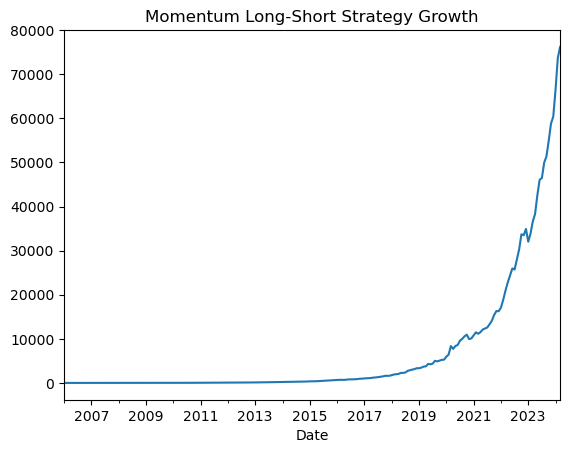

In [16]:
cumulative = (1 + strategy_returns).cumprod()

cumulative.plot(title="Momentum Long-Short Strategy Growth")

<Axes: title={'center': 'Strategy Drawdown'}, xlabel='Date'>

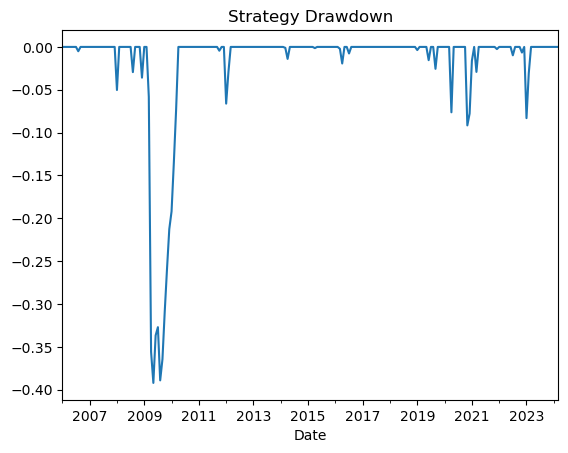

In [17]:
rolling_max = cumulative.cummax()
drawdown = (cumulative - rolling_max) / rolling_max

drawdown.plot(title="Strategy Drawdown")

In [18]:
df = pd.concat([strategy_returns, ff], axis=1).dropna()

df.columns = ['strategy', 'Mkt_RF', 'SMB', 'HML', 'RF']

In [19]:
y = df['strategy'] - df['RF']

In [20]:
print(type(ff.index))

<class 'pandas.core.indexes.period.PeriodIndex'>


In [21]:
strategy_returns.index = strategy_returns.index.to_period('M')

In [22]:
print("Strategy start/end:", strategy_returns.index.min(), strategy_returns.index.max())
print("FF start/end:", ff.index.min(), ff.index.max())

print("Common overlap:", len(strategy_returns.index.intersection(ff.index)))

Strategy start/end: 2006-01 2024-03
FF start/end: 1926-07 2026-02
Common overlap: 219


In [23]:
common_index = strategy_returns.index.intersection(ff.index)

strategy_aligned = strategy_returns.loc[common_index]
ff_aligned = ff.loc[common_index]

In [24]:
df = pd.concat([strategy_aligned, ff_aligned], axis=1)

df.columns = ['strategy', 'Mkt_RF', 'SMB', 'HML', 'RF']

df = df.dropna()

print(df.shape)

(219, 5)


# Regression 

In [25]:
import statsmodels.api as sm

y = df['strategy'] - df['RF']
X = sm.add_constant(df[['Mkt_RF', 'SMB', 'HML']])

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.368
Model:                            OLS   Adj. R-squared:                  0.360
Method:                 Least Squares   F-statistic:                     41.79
Date:                Tue, 21 Apr 2026   Prob (F-statistic):           2.56e-21
Time:                        17:10:56   Log-Likelihood:                 364.38
No. Observations:                 219   AIC:                            -720.8
Df Residuals:                     215   BIC:                            -707.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0572      0.003     17.925      0.0

In [26]:
# ==========================================
# VOLATILITY SCALING (ADD-ON)
# ==========================================

# Rolling volatility (12 months)
vol = strategy_returns.rolling(12).std()

# Target vol (15% annualized)
target_vol = 0.15 / np.sqrt(12)

# Scaling factor
scaling = target_vol / vol

# Clean scaling (avoid errors)
scaling = scaling.replace([np.inf, -np.inf], np.nan)
scaling = scaling.clip(upper=2)

# Apply scaling
vol_scaled_returns = (strategy_returns * scaling).dropna()

# Performance
sharpe_scaled = vol_scaled_returns.mean() / vol_scaled_returns.std() * np.sqrt(12)

print("Volatility Scaled Sharpe:", sharpe_scaled)

Volatility Scaled Sharpe: 4.09884722514875


<Axes: title={'center': 'Volatility Scaled Strategy'}, xlabel='Date'>

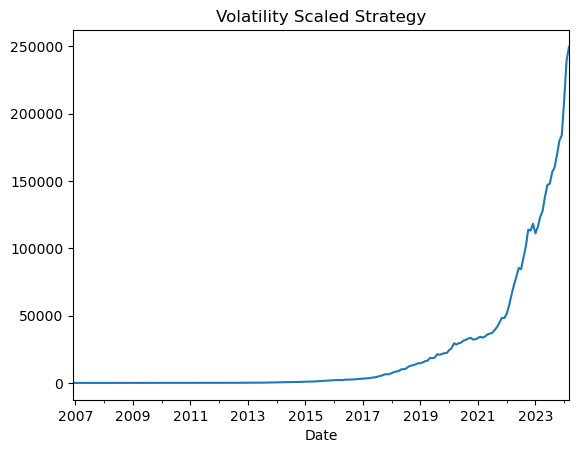

In [27]:
(1 + vol_scaled_returns).cumprod().plot(title="Volatility Scaled Strategy")

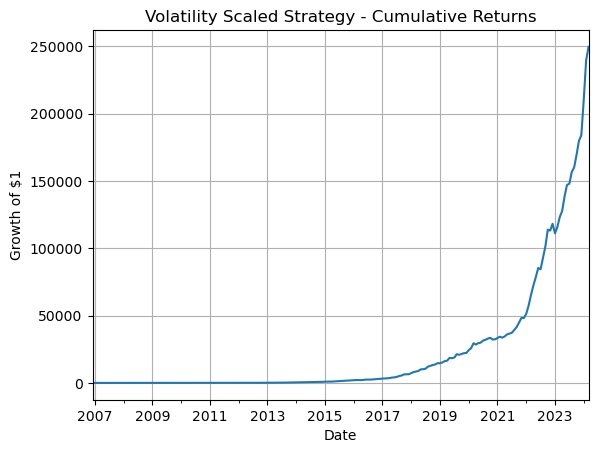

In [34]:
import matplotlib.pyplot as plt

# Cumulative returns
cum_vol_scaled = (1 + vol_scaled_returns).cumprod()

plt.figure()
cum_vol_scaled.plot()
plt.title("Volatility Scaled Strategy - Cumulative Returns")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid()
plt.show()

In [28]:
# ==========================================
# MARKET REGIME FILTER (ADD-ON)
# ==========================================

# Market excess return (already in ff)
market = ff['Mkt_RF']

# 12-month moving average
market_ma = market.rolling(12).mean()

# Regime signal (1 = invest, 0 = stay out)
regime = (market > market_ma).astype(int)

# Align with strategy
regime = regime.reindex(strategy_returns.index)

# Apply filter
regime_filtered_returns = (strategy_returns * regime).dropna()

# Performance
sharpe_regime = regime_filtered_returns.mean() / regime_filtered_returns.std() * np.sqrt(12)

print("Regime Filter Sharpe:", sharpe_regime)

Regime Filter Sharpe: 1.6449902354540993


<Axes: title={'center': 'Regime Filter Strategy'}, xlabel='Date'>

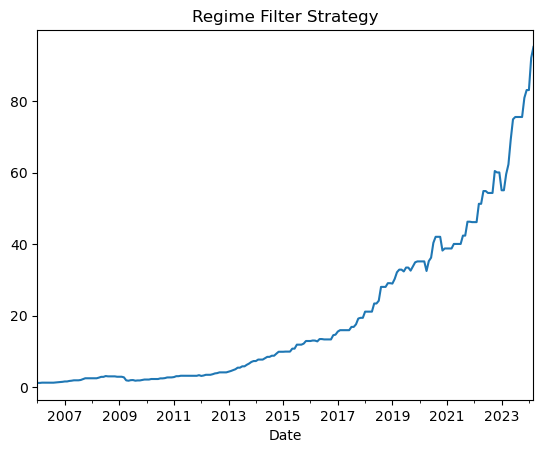

In [29]:
(1 + regime_filtered_returns).cumprod().plot(title="Regime Filter Strategy")

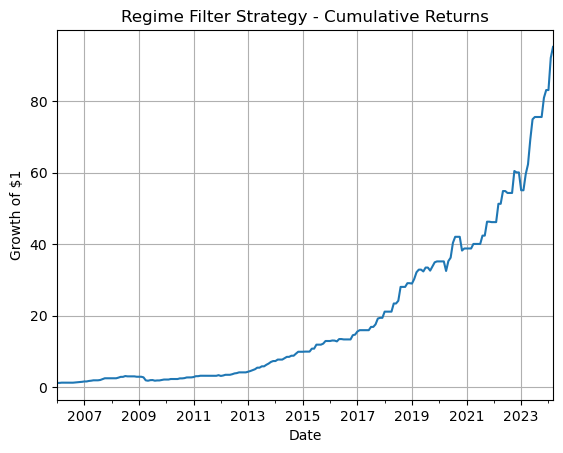

In [35]:
import matplotlib.pyplot as plt

cum_regime = (1 + regime_filtered_returns).cumprod()

plt.figure()
cum_regime.plot()
plt.title("Regime Filter Strategy - Cumulative Returns")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid()
plt.show()

In [30]:
# ==========================================
# COMBINED STRATEGY
# ==========================================

# Align everything (IMPORTANT but safe)
scaling = scaling.reindex(strategy_returns.index)
regime = regime.reindex(strategy_returns.index)

combined_returns = (strategy_returns * scaling * regime).dropna()

# Performance
sharpe_combined = combined_returns.mean() / combined_returns.std() * np.sqrt(12)

print("Combined Sharpe:", sharpe_combined)

Combined Sharpe: 2.0823640531380274


<Axes: title={'center': 'Final Strategy (Scaled + Regime)'}, xlabel='Date'>

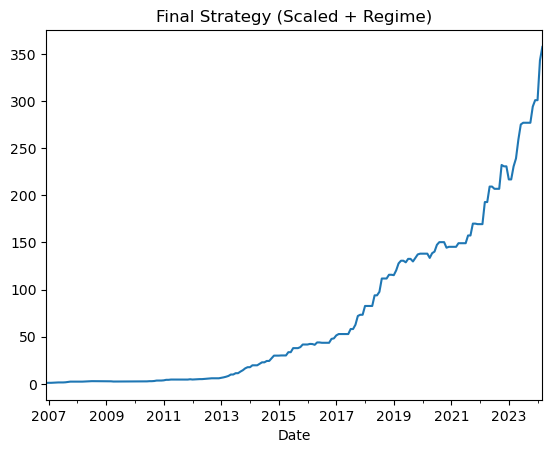

In [31]:
(1 + combined_returns).cumprod().plot(title="Final Strategy (Scaled + Regime)")

# Clean Graphs for presentation

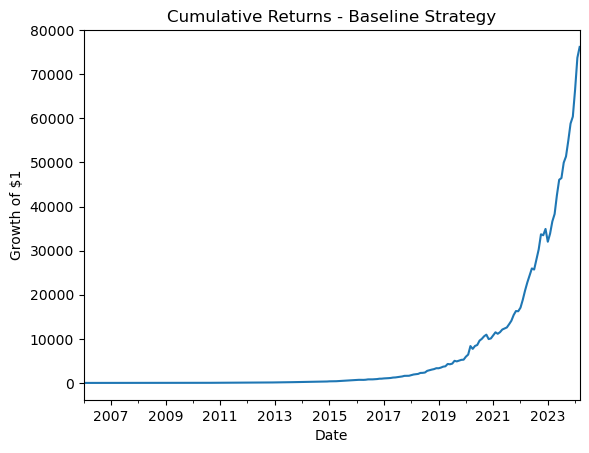

In [32]:
import matplotlib.pyplot as plt

cumulative = (1 + strategy_returns).cumprod()

plt.figure()
cumulative.plot()
plt.title("Cumulative Returns - Baseline Strategy")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.show()

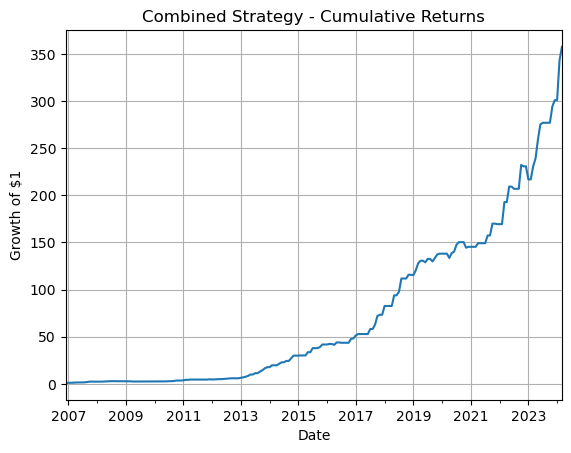

In [36]:
import matplotlib.pyplot as plt

cum_combined = (1 + combined_returns).cumprod()

plt.figure()
cum_combined.plot()
plt.title("Combined Strategy - Cumulative Returns")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid()
plt.show()

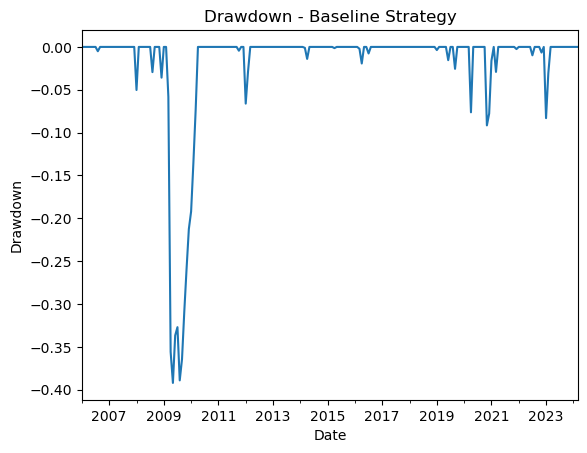

In [33]:
cum = (1 + strategy_returns).cumprod()
rolling_max = cum.cummax()
drawdown = (cum / rolling_max) - 1

plt.figure()
drawdown.plot()
plt.title("Drawdown - Baseline Strategy")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.show()

# Strategy Comparison 

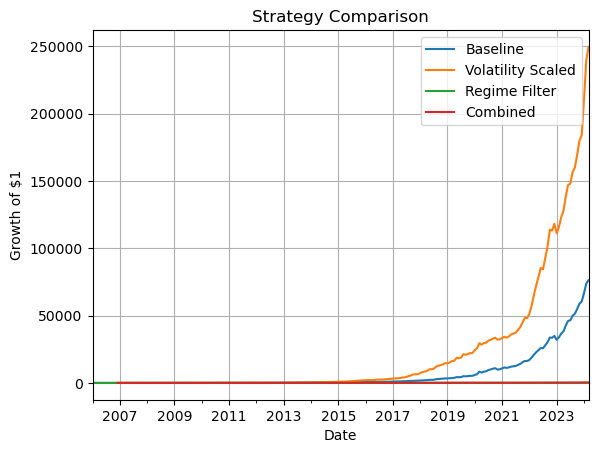

In [37]:
import matplotlib.pyplot as plt

plt.figure()

(1 + strategy_returns).cumprod().plot(label='Baseline')
(1 + vol_scaled_returns).cumprod().plot(label='Volatility Scaled')
(1 + regime_filtered_returns).cumprod().plot(label='Regime Filter')
(1 + combined_returns).cumprod().plot(label='Combined')

plt.title("Strategy Comparison")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid()
plt.show()

# Risk Analysis

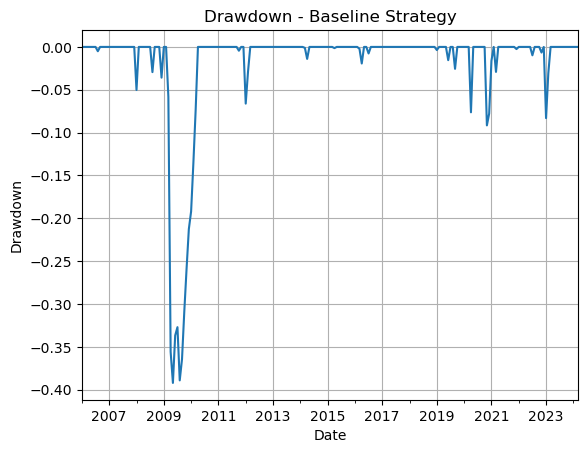

In [38]:
import matplotlib.pyplot as plt

cum = (1 + strategy_returns).cumprod()
rolling_max = cum.cummax()
drawdown = (cum / rolling_max) - 1

plt.figure()
drawdown.plot()
plt.title("Drawdown - Baseline Strategy")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid()
plt.show()